In [24]:
%load_ext dotenv 
%dotenv
%load_ext mypy_ipython

In [1]:
import config
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

C:\Users\moham\anaconda3\envs\langgraph_env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## DEFING THE STATE OF THE GRPAH 

In [2]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [3]:
state= State(messages=[HumanMessage("Could you tell a name for my cat")])

In [4]:
state

{'messages': [HumanMessage(content='Could you tell a name for my cat', additional_kwargs={}, response_metadata={})]}

In [5]:
state["messages"][0]

HumanMessage(content='Could you tell a name for my cat', additional_kwargs={}, response_metadata={})

In [6]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell a name for my cat


## DEFINE THE NODES (USER DEFINED NODES)

In [7]:
chat = ChatOpenAI(
    model="gpt-3.5-turbo",
    seed= 365,
    temperature=0,
    max_completion_tokens=50,
    openai_api_key = config.api_key
)

In [8]:
response = chat.invoke(state["messages"])

In [9]:
response

AIMessage(content='Sure! How about Luna?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 15, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DUEV9VAjFfW8BBgL0sTUx2PGDcWq3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87b0-076e-7883-8fc2-7d5bb2d829be-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 6, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
response.pretty_print()

================================== Ai Message ==================================

Sure! How about Luna?


In [14]:
def chatbot (state: State) -> State:
    print(f"\n--------> ENTERING CHATBOT")

    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [15]:
chatbot(state)


--------> ENTERING CHATBOT
================================== Ai Message ==================================

Sure! How about Luna?


{'messages': [AIMessage(content='Sure! How about Luna?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 15, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DUEZe67dIwxqaj0Zuhe4XTdHVbpC8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87b4-4b24-7882-b2a5-469d21d0f56b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 6, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

## DEFINE THE GRPAH (CONNECT THE NODES)

In [17]:
graph = StateGraph(State) ## here pass the schema i.e state class defined above

In [18]:
graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [19]:
graph_compiled = graph.compile()

#This necessary step performs checks to ensure the graph is connected correctly.
#Additionally, it It converts our state graph into a compiled state graph.
#A runnable object.



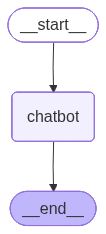

In [20]:
graph_compiled

### TEST THE GRAPH

In [22]:
graph_compiled.invoke(state)


--------> ENTERING CHATBOT
================================== Ai Message ==================================

Sure! How about Luna?


{'messages': [AIMessage(content='Sure! How about Luna?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 15, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DUEewhJvD4ylXFXZmikCcvngsMP0p', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d87b9-506a-7b61-a737-cb02180c8359-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 6, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

So let's summarize.

First, we implemented a class inherited from the typed dictionary class that defined our schema.

Second, we defined a graph node as a Python function that updates the value of the message key with

a model's response.

Third, we constructed the graph by adding the chatbot node and connecting it to the start and end nodes.

Fourth, we compiled the graph, a process that checks whether the graph is connected correctly and

produces a runnable object that can be invoked and easily visualized.

The fifth and final step invoked the compiled graph with the state defined earlier.

Nice.

Finally, as promised, let's check the type hinting within the notebook In a new cell.

Invoke and run the Mypy magic command while you wait for the results.



In [25]:
%mypy

    chat = ChatOpenAI(
error: Unexpected keyword argument "openai_api_key" for "ChatOpenAI"  [call-arg]
    chatbot(state)
error: Name "chatbot" is used before definition  [used-before-def]
    graph = StateGraph(state) ## here pass the schema 
error: Need type annotation for "graph"  [var-annotated]
    graph = StateGraph(state) ## here pass the schema 
error: Argument 1 to "StateGraph" has incompatible type "State"; expected "type[Never]"  [arg-type]
Found 4 errors in 1 file (checked 1 source file)


Type checking failed
